# Análise de Dados - Tênis de Corrida RunRepeat

## 4. Visualização de Dados Bivariada (2D)

Análise de relações entre pares de variáveis usando scatter plots, boxplots agrupados e gráficos de barras empilhadas.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

df = pd.read_csv('tenis_scraper_runrepeat/dados_finais/runrepeat_shoes_complete.csv')
print(f'✅ Dataset carregado: {df.shape}')

✅ Dataset carregado: (530, 46)


## 4.1 Scatter Plot - Preço vs Audience Score

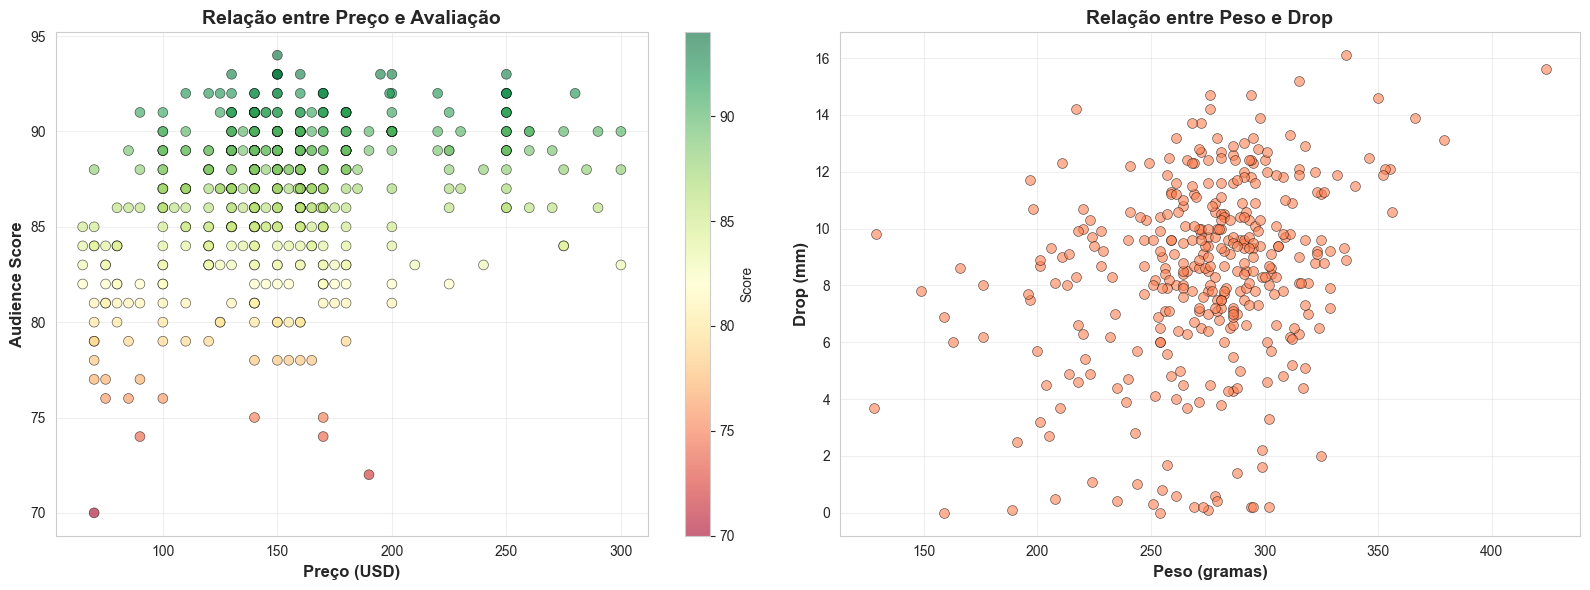


📊 INTERPRETAÇÃO:
• Preço e Score têm correlação fraca - qualidade não depende apenas do preço
• Peso e Drop mostram alguma variação - tênis mais leves tendem a ter drops variados


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter 1: Preço vs Score
ax1 = axes[0]
scatter = ax1.scatter(df['price_usd'], df['audience_score'], 
                      alpha=0.6, c=df['audience_score'], cmap='RdYlGn', s=50, edgecolors='black', linewidth=0.5)
ax1.set_xlabel('Preço (USD)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Audience Score', fontsize=12, fontweight='bold')
ax1.set_title('Relação entre Preço e Avaliação', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=ax1, label='Score')
ax1.grid(alpha=0.3)

# Scatter 2: Peso vs Drop
ax2 = axes[1]
ax2.scatter(df['weight_grams'], df['drop_mm'], alpha=0.6, c='coral', s=50, edgecolors='black', linewidth=0.5)
ax2.set_xlabel('Peso (gramas)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Drop (mm)', fontsize=12, fontweight='bold')
ax2.set_title('Relação entre Peso e Drop', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('\n📊 INTERPRETAÇÃO:')
print('• Preço e Score têm correlação fraca - qualidade não depende apenas do preço')
print('• Peso e Drop mostram alguma variação - tênis mais leves tendem a ter drops variados')

## 4.2 Boxplot Agrupado - Preço por Marca

/var/folders/bm/6syztstn3cjbv23rnpzd4gj00000gn/T/ipykernel_45440/1423757618.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, y='brand', x='price_usd', order=top_brands, ax=ax1, palette='Set2')
/var/folders/bm/6syztstn3cjbv23rnpzd4gj00000gn/T/ipykernel_45440/1423757618.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='arch support', y='audience_score', ax=ax2, palette='coolwarm')


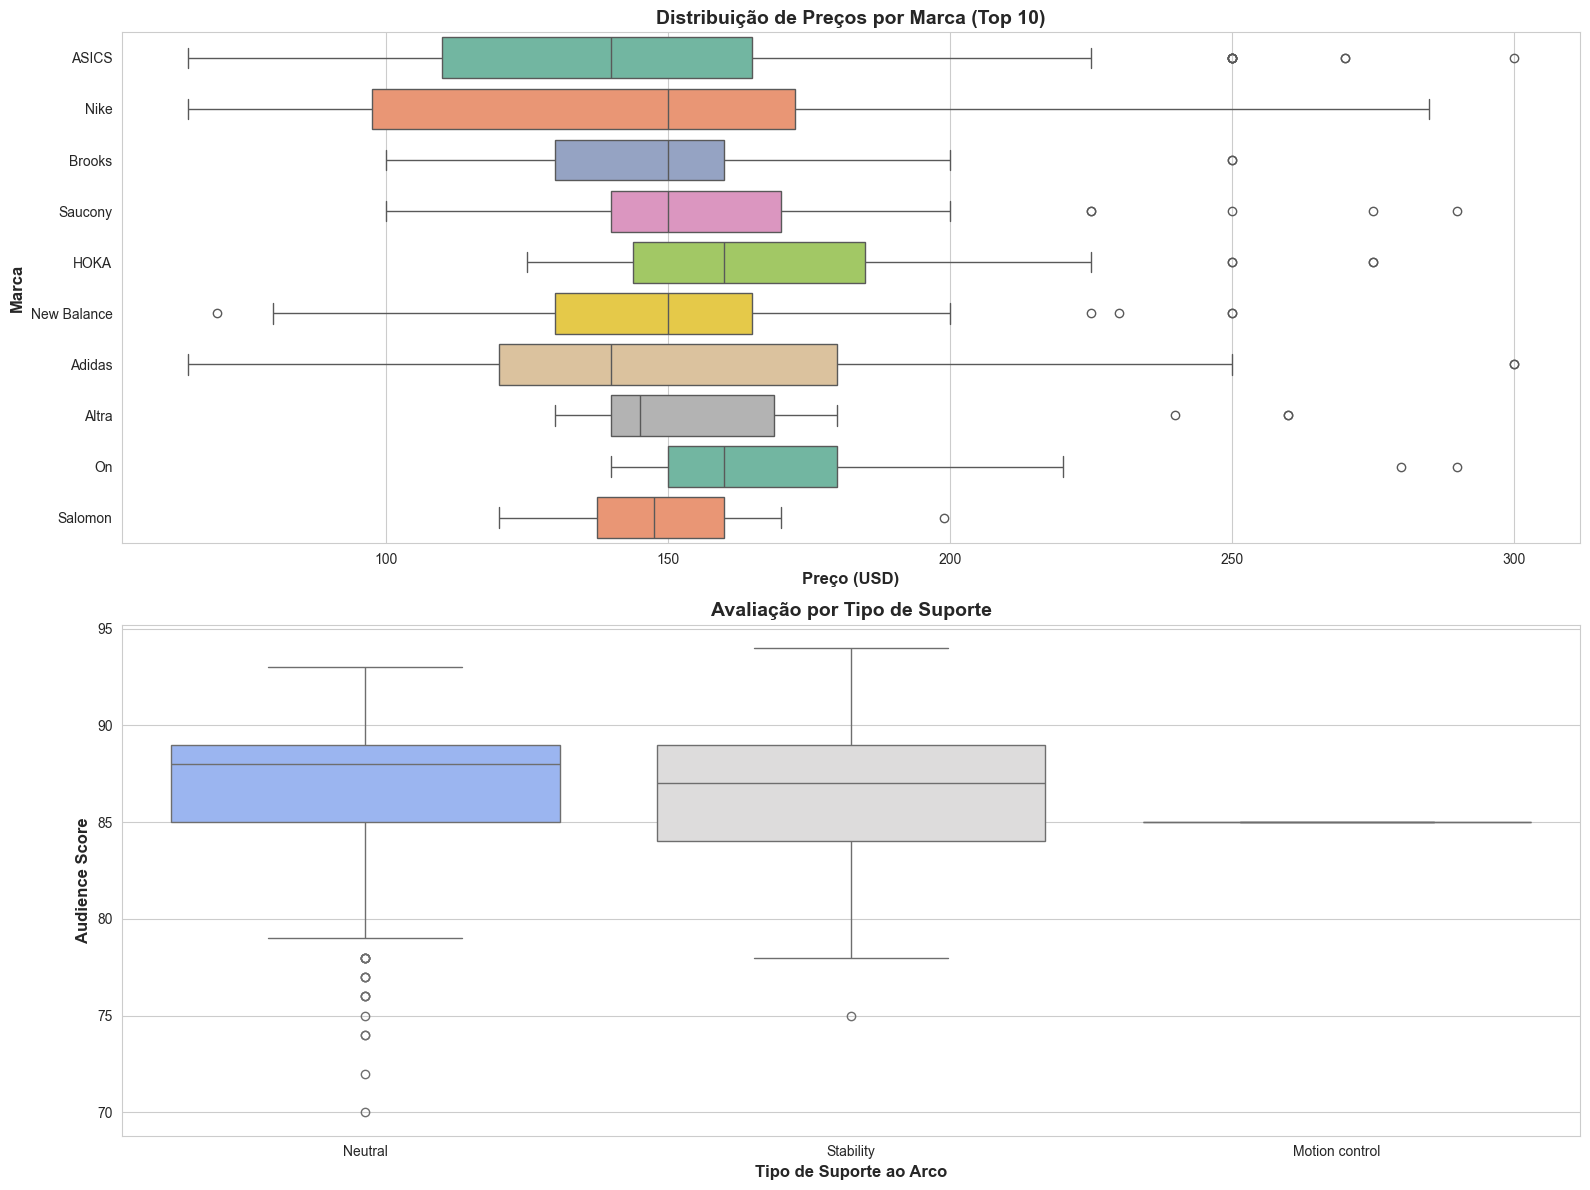


📊 INTERPRETAÇÃO:
• Marcas premium têm maior variação de preços
• Tipo de suporte não afeta significativamente a avaliação


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Boxplot 1: Preço por Marca (Top 10)
ax1 = axes[0]
top_brands = df['brand'].value_counts().head(10).index
df_top = df[df['brand'].isin(top_brands)]
sns.boxplot(data=df_top, y='brand', x='price_usd', order=top_brands, ax=ax1, palette='Set2')
ax1.set_xlabel('Preço (USD)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Marca', fontsize=12, fontweight='bold')
ax1.set_title('Distribuição de Preços por Marca (Top 10)', fontsize=14, fontweight='bold')

# Boxplot 2: Score por Tipo de Suporte
ax2 = axes[1]
sns.boxplot(data=df, x='arch support', y='audience_score', ax=ax2, palette='coolwarm')
ax2.set_xlabel('Tipo de Suporte ao Arco', fontsize=12, fontweight='bold')
ax2.set_ylabel('Audience Score', fontsize=12, fontweight='bold')
ax2.set_title('Avaliação por Tipo de Suporte', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n📊 INTERPRETAÇÃO:')
print('• Marcas premium têm maior variação de preços')
print('• Tipo de suporte não afeta significativamente a avaliação')

## 4.3 Barras Empilhadas - Marca vs Tipo de Suporte

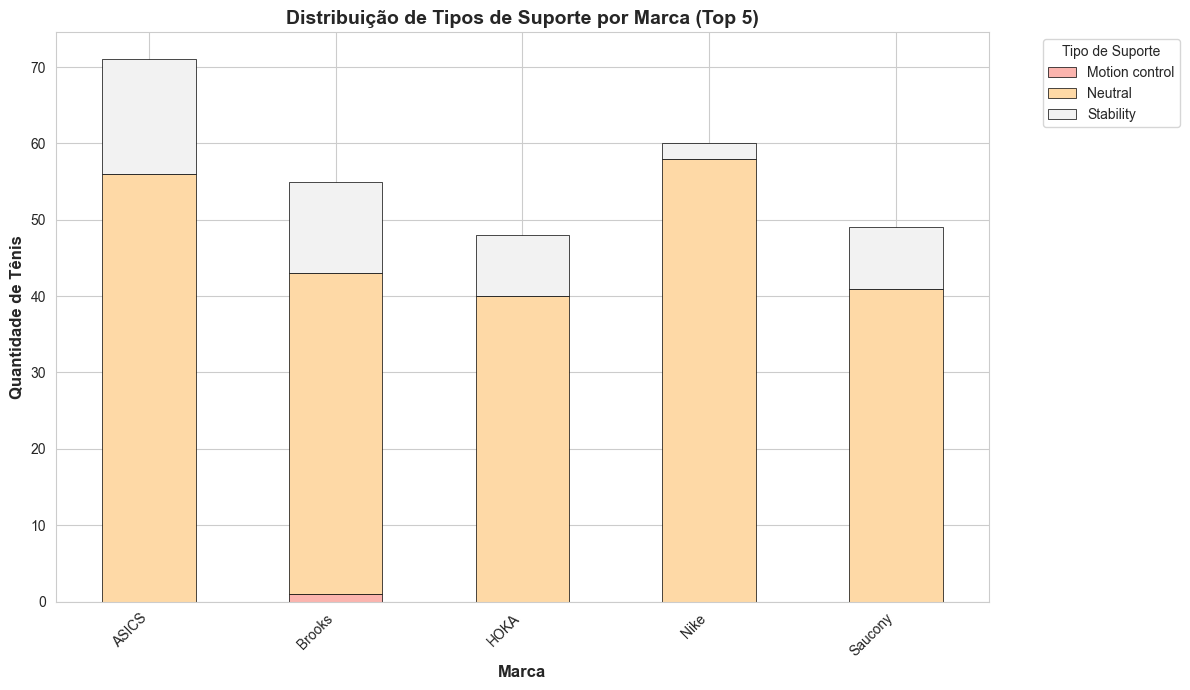


📊 INTERPRETAÇÃO:
• Cada marca tem diferentes proporções de tipos de suporte
• Neutral é o tipo mais comum em todas as marcas


In [8]:
# Crosstab
top5_brands = df['brand'].value_counts().head(5).index
df_cross = df[df['brand'].isin(top5_brands)]
cross_tab = pd.crosstab(df_cross['brand'], df_cross['arch support'])

fig, ax = plt.subplots(figsize=(12, 7))
cross_tab.plot(kind='bar', stacked=True, ax=ax, colormap='Pastel1', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Marca', fontsize=12, fontweight='bold')
ax.set_ylabel('Quantidade de Tênis', fontsize=12, fontweight='bold')
ax.set_title('Distribuição de Tipos de Suporte por Marca (Top 5)', fontsize=14, fontweight='bold')
ax.legend(title='Tipo de Suporte', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\n📊 INTERPRETAÇÃO:')
print('• Cada marca tem diferentes proporções de tipos de suporte')
print('• Neutral é o tipo mais comum em todas as marcas')